# 18. Neural Networks II: Backpropagation
@Shengli (Bruce) Jiang, University of South Carolina

## What We Covered in the Last Lecture

A neural network is a sequence of layers that transforms inputs into predictions.

- Weights and biases are the parameters learned from data.
- Hidden layers build intermediate representations.
- Activation functions add nonlinearity.
- Forward propagation computes the prediction.
- TensorFlow/Keras provides a convenient way to build and train neural networks.

## Today's Learning Objectives

By the end of this notebook, you should be able to:

1. Match common loss functions to regression and classification tasks.
2. Explain what backpropagation calculates and how the chain rule is used.
3. Perform one gradient-descent update for a small neural network.
4. Separate training, validation, and test data by their roles.
5. Build, tune, and evaluate a simple fully connected network for MNIST.

## Running the Notebook

TensorFlow will download MNIST the first time it is needed. Run the cells from top to bottom.

The code uses `random_seed=26` so the data split and model initialization are reproducible.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(26)

## 1. Loss Functions

A loss function measures the difference between the model prediction and the true target.

For regression,

$$
\mathrm{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

$$
\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

For classification, cross-entropy penalizes low probability assigned to the correct class. For one sample with one-hot target $\mathbf{y}$,

$$
L=-\sum_{k=1}^{K}y_k\log(p_k).
$$

For integer class labels such as MNIST digits, Keras uses `sparse_categorical_crossentropy`.

In [2]:
y_true_reg = np.array([2.0, 4.0, 6.0])
y_pred_reg = np.array([2.5, 3.5, 5.0])

mse = np.mean((y_true_reg - y_pred_reg) ** 2)
mae = np.mean(np.abs(y_true_reg - y_pred_reg))

p_correct = np.array([0.9, 0.6, 0.1])
cross_entropy = -np.log(p_correct)

print("Regression MSE:", round(mse, 3))
print("Regression MAE:", round(mae, 3))
print()
display(pd.DataFrame({
    "Probability of correct class": p_correct,
    "Cross-entropy loss": cross_entropy
}).round(3))

Regression MSE: 0.5
Regression MAE: 0.667



,Probability of correct class,Cross-entropy loss
0,0.9,0.105
1,0.6,0.511
2,0.1,2.303


A confident correct prediction has small cross-entropy loss. A confident wrong prediction has large loss.

This is the signal that backpropagation sends backward through the network.

## 2. Backpropagation: One Worked Update

Consider the small network used in the lecture:

- input: $x=[1,2,-1]$
- hidden layer: 2 linear units
- output: 1 linear unit
- target: $y=1$
- learning rate: $\eta=0.1$

The forward pass is

$$
\mathbf{h}=\mathbf{x}W^{(1)}+\mathbf{b}^{(1)}
$$

$$
\hat{y}=\mathbf{h}W^{(2)}+b^{(2)}
$$

and the loss is

$$
L=(\hat{y}-y)^2.
$$

We use linear units here so the chain rule is easy to see. The MNIST model later uses ReLU and softmax.

In [3]:
x_bp = np.array([1.0, 2.0, -1.0])
y_bp = 1.0

W1 = np.array([
    [0.2, 0.1],
    [0.3, 0.4],
    [-0.5, 0.3]
])
b1 = np.array([0.7, -0.9])

W2 = np.array([0.5, 0.4])
b2 = -0.3

h = x_bp @ W1 + b1
y_hat = h @ W2 + b2
loss = (y_hat - y_bp) ** 2

print("Hidden layer:", h)
print("Prediction:", round(y_hat, 4))
print("Loss:", round(loss, 4))

Hidden layer: [ 2.  -0.3]
Prediction: 0.58
Loss: 0.1764


### Chain Rule

Backpropagation starts at the loss and moves backward.

For the output,

$$
\frac{\partial L}{\partial \hat{y}}=2(\hat{y}-y).
$$

Then,

$$
\frac{\partial L}{\partial W^{(2)}}=
\frac{\partial L}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial W^{(2)}}
$$

and the gradient continues backward to the hidden layer and then to $W^{(1)}$.

All gradients are calculated from the same forward pass. Parameters are updated only after the gradients are known.

In [4]:
learning_rate = 0.1

dL_dy_hat = 2 * (y_hat - y_bp)

grad_W2 = h * dL_dy_hat
grad_b2 = dL_dy_hat

grad_h = W2 * dL_dy_hat
grad_W1 = np.outer(x_bp, grad_h)
grad_b1 = grad_h

print("dL/dy_hat:", round(dL_dy_hat, 4))
print("Gradient for W2:", grad_W2)
print("Gradient for b2:", round(grad_b2, 4))
print()
print("Gradient for W1:")
print(grad_W1)
print("Gradient for b1:", grad_b1)

dL/dy_hat: -0.84
Gradient for W2: [-1.68   0.252]
Gradient for b2: -0.84

Gradient for W1:
[[-0.42  -0.336]
 [-0.84  -0.672]
 [ 0.42   0.336]]
Gradient for b1: [-0.42  -0.336]


### Gradient-Descent Update

Each parameter moves in the direction opposite its gradient:

$$
\theta_{\mathrm{new}}=\theta_{\mathrm{old}}-\eta\frac{\partial L}{\partial\theta}.
$$

In [5]:
W1_new = W1 - learning_rate * grad_W1
b1_new = b1 - learning_rate * grad_b1
W2_new = W2 - learning_rate * grad_W2
b2_new = b2 - learning_rate * grad_b2

parameter_updates = pd.DataFrame({
    "Parameter": [
        "W1[0,0]", "W1[0,1]", "W1[1,0]", "W1[1,1]",
        "W1[2,0]", "W1[2,1]", "b1[0]", "b1[1]",
        "W2[0]", "W2[1]", "b2"
    ],
    "Old": [
        W1[0, 0], W1[0, 1], W1[1, 0], W1[1, 1],
        W1[2, 0], W1[2, 1], b1[0], b1[1],
        W2[0], W2[1], b2
    ],
    "New": [
        W1_new[0, 0], W1_new[0, 1], W1_new[1, 0], W1_new[1, 1],
        W1_new[2, 0], W1_new[2, 1], b1_new[0], b1_new[1],
        W2_new[0], W2_new[1], b2_new
    ]
})

display(parameter_updates.round(4))

,Parameter,Old,New
0,"W1[0,0]",0.2,0.2420
1,"W1[0,1]",0.1,0.1336
2,"W1[1,0]",0.3,0.3840
3,"W1[1,1]",0.4,0.4672
4,"W1[2,0]",-0.5,-0.5420
5,"W1[2,1]",0.3,0.2664
6,b1[0],0.7,0.7420
7,b1[1],-0.9,-0.8664
8,W2[0],0.5,0.6680
9,W2[1],0.4,0.3748


In [6]:
h_new = x_bp @ W1_new + b1_new
y_hat_new = h_new @ W2_new + b2_new
loss_new = (y_hat_new - y_bp) ** 2

comparison = pd.DataFrame({
    "": ["Before update", "After update"],
    "Prediction": [y_hat, y_hat_new],
    "Loss": [loss, loss_new]
})

display(comparison.round(4))
print("Updated hidden layer:", np.round(h_new, 4))

,,Prediction,Loss
0,Before update,0.5800,0.1764
1,After update,1.2921,0.0853


Updated hidden layer: [ 2.294  -0.0648]


The prediction changes from about 0.58 to 1.29, while the loss decreases from about 0.176 to 0.085.

Backpropagation does not choose the architecture. It calculates how the loss changes with each trainable parameter. The optimizer uses those gradients to update the parameters.

## 3. Training, Validation, and Test Data

In this notebook we separate two validation roles so the model-selection logic is explicit.

| Data | Role |
|---|---|
| Training | Update weights and biases |
| Validation 1 | Select the best epoch or best weights for one model |
| Validation 2 | Compare hyperparameter settings |
| Test | Final evaluation after model selection |

The test set should not be used to choose the hidden-layer size, learning rate, batch size, or number of epochs.

## 4. MNIST Classification

MNIST contains handwritten digits from 0 to 9.

- 60,000 images are provided in the original training set.
- 10,000 images are reserved as the test set.
- Each image is $28\times28$ grayscale pixels.
- The task has 10 classes.

In [7]:
(x_all, y_all), (x_test, y_test) = keras.datasets.mnist.load_data()

x_all = x_all.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Full training data:", x_all.shape, y_all.shape)
print("Test data:", x_test.shape, y_test.shape)
print("Pixel range:", x_all.min(), "to", x_all.max())

Full training data: (60000, 28, 28) (60000,)
Test data: (10000, 28, 28) (10000,)
Pixel range: 0.0 to 1.0


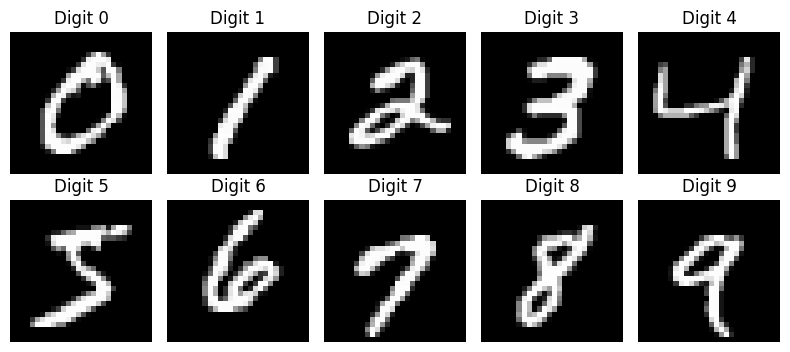

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3.6))

for digit, ax in enumerate(axes.flat):
    first_match = np.flatnonzero(y_all == digit)[0]
    ax.imshow(x_all[first_match], cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")

fig.tight_layout()
plt.show()

## 5. Create the Train and Validation Sets

We shuffle the original 60,000 training images and split them into:

- 48,000 training samples
- 6,000 Validation 1 samples
- 6,000 Validation 2 samples

The 10,000 test images remain untouched.

In [9]:
rng = np.random.default_rng(26)
idx = rng.permutation(len(x_all))

x_shuffled = x_all[idx]
y_shuffled = y_all[idx]

x_train, y_train = x_shuffled[:48000], y_shuffled[:48000]
x_val1, y_val1 = x_shuffled[48000:54000], y_shuffled[48000:54000]
x_val2, y_val2 = x_shuffled[54000:], y_shuffled[54000:]

split_sizes = pd.Series({
    "Training": len(x_train),
    "Validation 1": len(x_val1),
    "Validation 2": len(x_val2),
    "Test": len(x_test)
}, name="Samples")

display(split_sizes.to_frame())

,Samples
Training,48000
Validation 1,6000
Validation 2,6000
Test,10000


## 6. Build a Fully Connected Neural Network

The model has four steps:

1. `Input`: accept a $28\times28$ image.
2. `Flatten`: convert the image to 784 numbers.
3. `Dense`: learn a hidden representation with ReLU.
4. `Dense(10, softmax)`: return probabilities for digits 0 through 9.

We use Adam for optimization and sparse categorical cross-entropy because the labels are integers.

In [10]:
def build_model(n_hidden):
    model = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(n_hidden, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


example_model = build_model(64)
example_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Hyperparameter Tuning

We compare two hidden-layer sizes: 64 and 128 neurons.

For each model:

1. Train on the training set for up to 20 epochs.
2. Use Validation 1 loss to save the best weights.
3. Restore those weights.
4. Evaluate the model on Validation 2.
5. Select the hidden-layer size with the highest Validation 2 accuracy.

This is a small teaching example, not an exhaustive hyperparameter search.

In [11]:
models = {}
histories = {}
tuning_rows = []

for n_hidden in [64, 128]:
    model = build_model(n_hidden)
    path = f"best_{n_hidden}.weights.h5"

    checkpoint = keras.callbacks.ModelCheckpoint(
        path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val1, y_val1),
        epochs=20,
        batch_size=128,
        callbacks=[checkpoint],
        verbose=0
    )

    model.load_weights(path)
    val2_loss, val2_acc = model.evaluate(x_val2, y_val2, verbose=0)

    models[n_hidden] = model
    histories[n_hidden] = history.history

    tuning_rows.append({
        "Hidden units": n_hidden,
        "Validation 2 loss": val2_loss,
        "Validation 2 accuracy": val2_acc
    })

tuning_results = pd.DataFrame(tuning_rows)
display(tuning_results.round(4))

best_row = tuning_results["Validation 2 accuracy"].idxmax()
best_hidden = int(tuning_results.loc[best_row, "Hidden units"])
best_model = models[best_hidden]

print("Selected hidden units:", best_hidden)

,Hidden units,Validation 2 loss,Validation 2 accuracy
0,64,0.1132,0.968
1,128,0.0897,0.973


Selected hidden units: 128


## 8. Read the Training Curves

Training loss shows how well the model fits the data used to update the weights. Validation loss shows how well the same model generalizes to Validation 1 after each epoch.

A growing gap between the two curves can be a sign of overfitting.

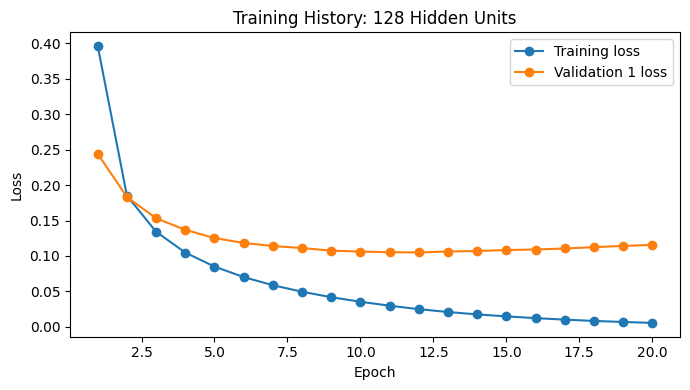

In [12]:
selected_history = histories[best_hidden]
epochs = np.arange(1, len(selected_history["loss"]) + 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, selected_history["loss"], marker="o", label="Training loss")
ax.plot(epochs, selected_history["val_loss"], marker="o", label="Validation 1 loss")
ax.set(
    xlabel="Epoch",
    ylabel="Loss",
    title=f"Training History: {best_hidden} Hidden Units"
)
ax.legend()

fig.tight_layout()
plt.show()

## 9. Final Test Evaluation

The hidden-layer size has already been selected, so we can now use the test set.

This final test estimates performance on data that did not participate in training or model selection.

In [13]:
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))

Test loss: 0.0881
Test accuracy: 0.9748


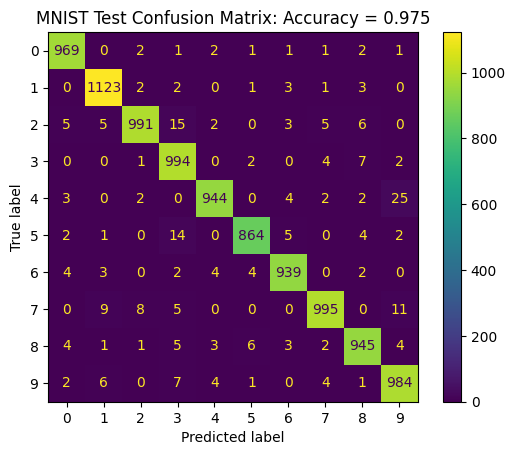

In [14]:
y_pred = np.argmax(best_model.predict(x_test, verbose=0), axis=1)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    values_format="d"
)

plt.title(f"MNIST Test Confusion Matrix: Accuracy = {test_acc:.3f}")
plt.show()

The diagonal entries are correct predictions. Off-diagonal entries show which digits the model confuses.

A single accuracy value is useful, but the confusion matrix shows where the remaining errors occur.